In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU, Conv2D, MaxPool2D, GlobalAvgPool2D , RandomFlip , RandomZoom , SpatialDropout2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.datasets import mnist , fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import load_iris , make_classification
from tensorflow.keras.utils import to_categorical , image_dataset_from_directory
import os

In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [23]:
print(os.listdir(path))

['Training', 'Testing']


In [24]:
SEED             = 42
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 64
VAL_SPLIT        = 0.20
HEAD_EPOCHS      = 8
FINE_TUNE_EPOCHS = 5
HEAD_WEIGHTS     = "best_head.weights.h5"
FINE_WEIGHTS     = "best_fine.weights.h5"

In [25]:
train_dir ="/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

In [26]:
from pathlib import Path

train_dir = Path(train_dir)
test_dir = Path(test_dir)

In [27]:
print(type(train_dir))

<class 'pathlib.PosixPath'>


In [28]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [29]:
class_names = train_ds.class_names
print(class_names)
print("Number of classes:", len(class_names))

['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


In [30]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [31]:
def count_images(folder):
    """Count all image files in a folder."""
    total = 0
    for pattern in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
        total += len(list(folder.glob(pattern)))
    return total
print("Training images:")
for name in class_names:
    print(f"  {name}: {count_images(train_dir / name)}")
print("\nTesting images:")
for name in class_names:
    print(f"  {name}: {count_images(test_dir / name)}")

Training images:
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400

Testing images:
  glioma: 400
  meningioma: 400
  notumor: 400
  pituitary: 400


In [32]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(64, 224, 224, 3)
(64, 4)


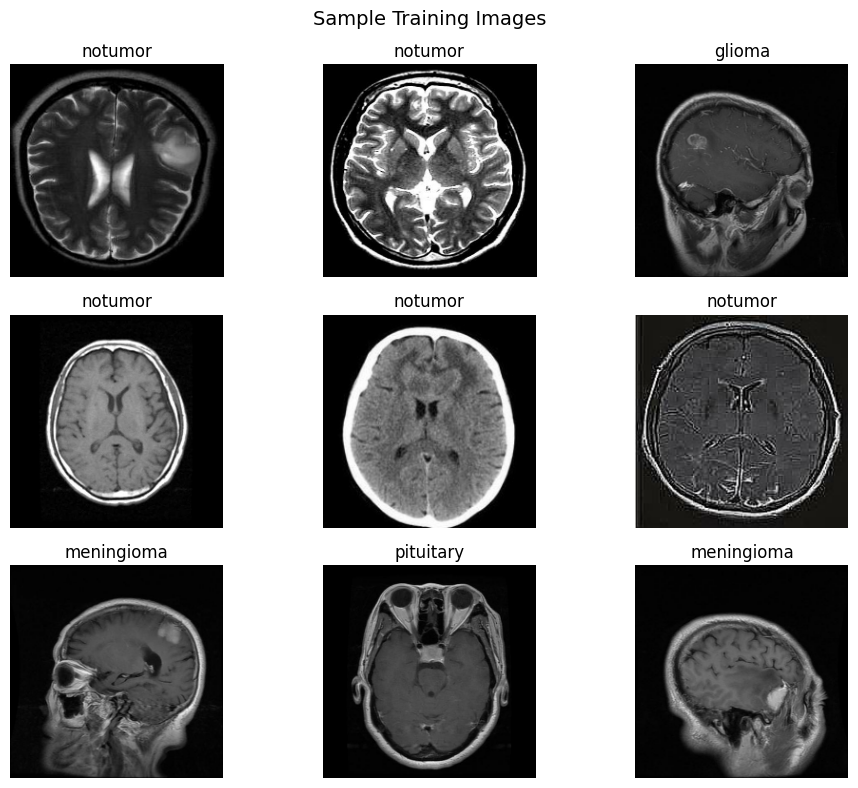

In [33]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = np.argmax(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
import albumentations as A
import cv2

In [35]:
albumentations_transform = A.Compose([
A.HorizontalFlip(p=0.5),
A.Rotate(limit=10, p=0.5),
])
A.RandomScale(scale_limit=0.15, p=0.5),
A.Affine(translate_percent=0.10, p=0.5),
A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
A.Resize(224, 224)

Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224)

In [36]:
def apply_albumentations(image, label):
   def aug_fn(img):
      img = img.numpy().astype('uint8')
      augmented = albumentations_transform(image=img)
      return augmented['image'].astype('float32')
   aug_img = tf.py_function(func=aug_fn, inp=[image], Tout=tf.float32)
   aug_img.set_shape(image.shape)
   return aug_img, label

In [37]:
train_ds = train_ds.unbatch()
train_ds = train_ds.map(apply_albumentations, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [43]:

from tensorflow.keras import models, layers
from tensorflow.keras.regularizers import l2

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),



    layers.Conv2D(32, (3,3), padding='same',
                  activation='relu',
                  kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same',
                  activation='relu',
                  kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same',
                  activation='relu',
                  kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same',
                  activation='relu',
                  kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),

    layers.Dense(256,
                 activation='relu',
                 kernel_regularizer=l2(1e-4)),

    layers.Dropout(0.4),

    layers.Dense(4, activation='softmax')
])

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [44]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [46]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
     70/Unknown 43s 339ms/step - accuracy: 0.5997 - loss: 1.0397

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


70/70 ━━━━━━━━━━━━━━━━━━━━ 51s 457ms/step - accuracy: 0.6701 - loss: 0.8857 - val_accuracy: 0.4170 - val_loss: 2.4763 - learning_rate: 0.0010
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 353ms/step - accuracy: 0.7696 - loss: 0.6582 - val_accuracy: 0.2598 - val_loss: 3.8765 - learning_rate: 0.0010
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 341ms/step - accuracy: 0.7926 - loss: 0.6134 - val_accuracy: 0.3259 - val_loss: 3.2547 - learning_rate: 0.0010
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 358ms/step - accuracy: 0.8161 - loss: 0.5342 - val_accuracy: 0.2562 - val_loss: 5.4039 - learning_rate: 0.0010
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 340ms/step - accuracy: 0.8464 - loss: 0.4645 - val_accuracy: 0.2777 - val_loss: 6.2619 - learning_rate: 2.0000e-04
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 339ms/step - accuracy: 0.8580 - loss: 0.4336 - val_accuracy: 0.3107 - val_loss: 5.0754 - learning_rate: 2.0000e-04
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 337ms/step - accuracy: 0.8578 - loss: 0.418

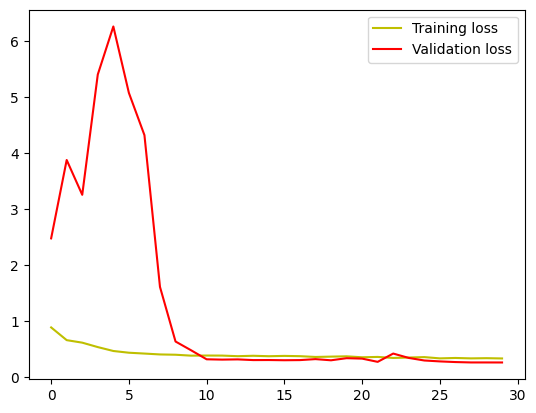

In [47]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, 'y', label='Training loss')
plt.plot(val_loss, 'r', label='Validation loss')
plt.legend()
plt.show()